<a href="https://colab.research.google.com/github/NeerajDangwal16/als-rnaseq-pipeline/blob/main/project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
if (!require("BiocManager", quietly = TRUE)) install.packages("BiocManager")
BiocManager::install(c("WGCNA", "impute", "preprocessCore"), update = FALSE, ask = FALSE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'BiocVersion', 'WGCNA', 'impute', 'preprocessCore'

also installing the dependencies ‘checkmate’, ‘gridExtra’, ‘htmlTable’, ‘colorspace’, ‘Formula’, ‘iterators’, ‘dynamicTreeCut’, ‘fastcluster’, ‘matrixStats’, ‘Hmisc’, ‘foreach’, ‘doParallel’




In [ ]:
library(WGCNA)
options(stringsAsFactors = FALSE)

counts <- read.table("GSE234297_normalized_counts.txt", header = TRUE, row.names = 1, sep = "\t")
cat("Loaded matrix dimensions:", dim(counts), "\n")

# This file already has samples as rows, genes as columns (from the Python export) — no transpose needed
datExpr <- counts
cat("datExpr dimensions (samples x genes):", dim(datExpr), "\n")

gene_var <- apply(datExpr, 2, var)
top_genes <- names(sort(gene_var, decreasing = TRUE))[1:5000]
datExpr <- datExpr[, top_genes]
cat("After variance filtering:", dim(datExpr), "\n")

gsg <- goodSamplesGenes(datExpr, verbose = 3)
cat("All good (no issues found)?", gsg$allOK, "\n")

if (!gsg$allOK) {
  datExpr <- datExpr[gsg$goodSamples, gsg$goodGenes]
  cat("After removing bad samples/genes:", dim(datExpr), "\n")
}

Loading required package: dynamicTreeCut

Loading required package: fastcluster


Attaching package: ‘fastcluster’


The following object is masked from ‘package:stats’:

    hclust



Attaching package: ‘WGCNA’


The following object is masked from ‘package:stats’:

    cor




Loaded matrix dimensions: 144 29867 
datExpr dimensions (samples x genes): 144 29867 
After variance filtering: 144 5000 
 Flagging genes and samples with too many missing values...
  ..step 1
All good (no issues found)? TRUE 


In [ ]:
file.info("GSE234297_normalized_counts.txt")$size

[1] 51600566

pickSoftThreshold: will use block size 5000.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 5000 of 5000


Warning message:
“executing %dopar% sequentially: no parallel backend registered”


   Power SFT.R.sq   slope truncated.R.sq mean.k. median.k. max.k.
1      1  0.80200  1.3300          0.938 1560.00  1610.000 2390.0
2      2  0.00149 -0.0284          0.433  707.00   698.000 1450.0
3      3  0.31000 -0.5400          0.623  378.00   351.000  963.0
4      4  0.48700 -0.8640          0.733  223.00   191.000  677.0
5      5  0.57900 -1.0600          0.798  140.00   111.000  492.0
6      6  0.64200 -1.1700          0.854   91.70    66.800  367.0
7      7  0.68600 -1.2800          0.892   62.50    42.000  282.0
8      8  0.72000 -1.3700          0.916   43.90    27.700  221.0
9      9  0.75700 -1.4200          0.944   31.60    18.800  175.0
10    10  0.76400 -1.4800          0.952   23.20    13.100  141.0
11    11  0.79000 -1.5100          0.967   17.30     9.240  115.0
12    12  0.80100 -1.5400          0.971   13.20     6.520   94.3
13    13  0.82800 -1.5400          0.982   10.20     4.720   78.1
14    14  0.84800 -1.5400          0.984    7.95     3.410   65.1
15    15  

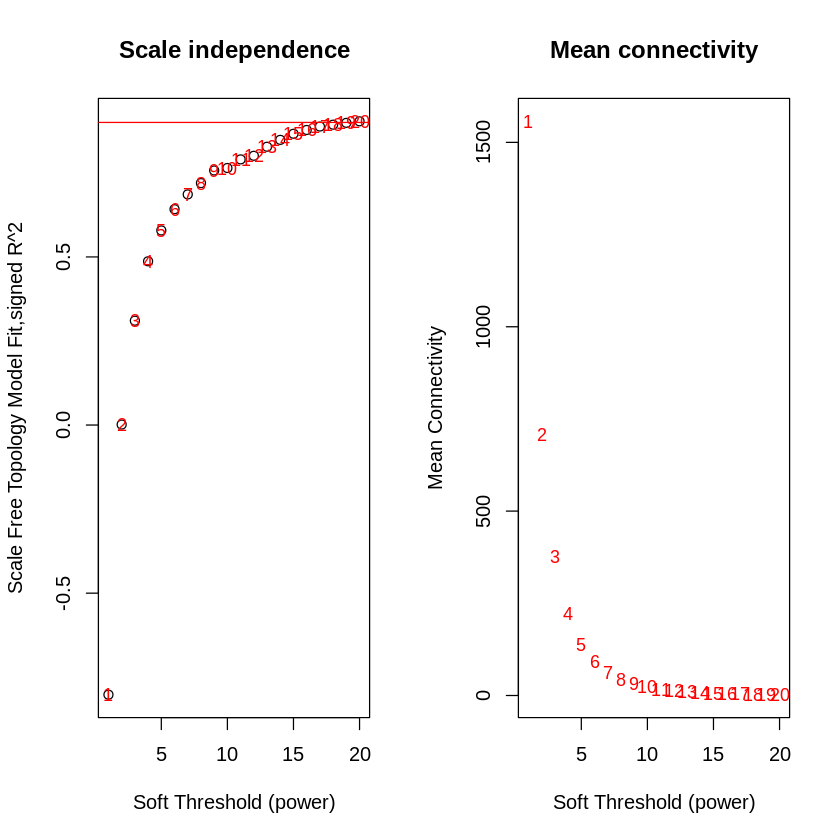

In [ ]:
powers <- c(1:20)
sft <- pickSoftThreshold(datExpr, powerVector = powers, verbose = 5)

# Plot to visually confirm the chosen power
par(mfrow = c(1,2))
plot(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
     xlab="Soft Threshold (power)", ylab="Scale Free Topology Model Fit,signed R^2",
     main = "Scale independence")
text(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2], labels=powers, cex=0.9, col="red")
abline(h=0.90, col="red")

plot(sft$fitIndices[,1], sft$fitIndices[,5],
     xlab="Soft Threshold (power)", ylab="Mean Connectivity", type="n",
     main = "Mean connectivity")
text(sft$fitIndices[,1], sft$fitIndices[,5], labels=powers, cex=0.9, col="red")

In [ ]:
net <- blockwiseModules(datExpr, power = 14,
                         TOMType = "unsigned", minModuleSize = 30,
                         reassignThreshold = 0, mergeCutHeight = 0.25,
                         numericLabels = TRUE, pamRespectsDendro = FALSE,
                         saveTOMs = FALSE,
                         verbose = 3)

table(net$colors)

 Calculating module eigengenes block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
 ..Working on block 1 .
    TOM calculation: adjacency..
    ..will not use multithreading.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
 ....clustering..
 ....detecting modules..
 ....calculating module eigengenes..
 ....checking kME in modules..
 ..merging modules that are too close..
     mergeCloseModules: Merging modules whose distance is less than 0.25
       Calculating new MEs...



   0    1    2    3    4    5    6    7    8    9   10 
1107 1110  772  735  352  321  204  173   93   74   59 

In [ ]:
pheno <- read.table("GSE234297_phenotype.txt", header = TRUE, sep = "\t")
pheno <- pheno[match(rownames(datExpr), pheno$sample), ]
stopifnot(all(rownames(datExpr) == pheno$sample))

traitData <- data.frame(ALS_status = ifelse(pheno$condition == "ALS", 1, 0))
rownames(traitData) <- pheno$sample

MEs <- net$MEs

moduleTraitCor <- cor(MEs, traitData, use = "p")
moduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nrow(datExpr))

result <- data.frame(
  module = rownames(moduleTraitCor),
  correlation = moduleTraitCor[,1],
  pvalue = moduleTraitPvalue[,1]
)
result <- result[order(abs(result$correlation), decreasing = TRUE), ]
print(result)

     module correlation      pvalue
ME0     ME0 -0.26498313 0.001328922
ME4     ME4  0.25595446 0.001958639
ME9     ME9  0.17376492 0.037262292
ME5     ME5  0.16721888 0.045148738
ME1     ME1  0.16530394 0.047703255
ME3     ME3 -0.14298127 0.087336721
ME8     ME8 -0.10461646 0.212073720
ME6     ME6  0.06645595 0.428712692
ME10   ME10 -0.04356461 0.604133639
ME7     ME7  0.03543540 0.673279596
ME2     ME2  0.02741861 0.744260076


In [ ]:
module_colors <- net$colors
me4_genes <- names(module_colors)[module_colors == 4]

cat("Number of genes in ME4:", length(me4_genes), "\n")
head(me4_genes)

write.table(me4_genes, "GSE234297_ME4_genes.txt", row.names = FALSE, col.names = FALSE, quote = FALSE)

Number of genes in ME4: 352 


[1] "X2215"  "X10628" "X3936"  "X4332"  "X9445"  "X9516"

In [ ]:
me4_genes_clean <- gsub("^X", "", me4_genes)

head(me4_genes_clean)

write.table(me4_genes_clean, "GSE234297_ME4_genes.txt", row.names = FALSE, col.names = FALSE, quote = FALSE)

[1] "2215"  "10628" "3936"  "4332"  "9445"  "9516"